In [6]:
import math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. Set global seed for reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 2. Complete MiniRacer Environment
class MiniRacer:
    SIZE, ACTIONS = 24, 3
    R, HALF_W, SPEED = 8.0, 2.2, 1.5
    GRASS = np.array([0.16, 0.34, 0.16], np.float32)
    ROAD  = np.array([0.44, 0.44, 0.46], np.float32)
    KERB  = np.array([0.75, 0.72, 0.62], np.float32)
    CAR   = np.array([0.92, 0.20, 0.15], np.float32)

    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
        c = (self.SIZE - 1) / 2.0
        yy, xx = np.mgrid[0:self.SIZE, 0:self.SIZE]
        rad = np.sqrt((xx - c)**2 + (yy - c)**2)
        
        self.track = np.tile(self.GRASS, (self.SIZE, self.SIZE, 1)).astype(np.float32)
        self.track[np.abs(rad - self.R) <= self.HALF_W] = self.ROAD
        self.track[np.abs(np.abs(rad - self.R) - self.HALF_W) <= 0.45] = self.KERB
        self._c = c
        self.reset()

    def reset(self):
        self.theta = self.rng.uniform(0, 2 * np.pi)
        self.d = self.rng.uniform(-1.0, 1.0)
        self.phi = self.rng.uniform(-0.2, 0.2)
        self.direction = int(self.rng.choice([-1, 1]))  # Hidden coin flip
        self.t = 0
        return self.observe()

    @property
    def state(self):
        return np.array([self.theta, self.d, self.phi, self.direction], np.float32)

    def observe(self):
        img = self.track.copy()
        r = self.R + self.d
        x = self._c + r * np.cos(self.theta)
        y = self._c + r * np.sin(self.theta)
        xi, yi = int(round(x)), int(round(y))
        for dx in (0, 1):
            for dy in (0, 1):
                px, py = xi + dx - 1, yi + dy - 1
                if 0 <= px < self.SIZE and 0 <= py < self.SIZE:
                    img[py, px] = self.CAR
        return img

    def step(self, action):
        self.phi = float(np.clip(self.phi + 0.16 * (action - 1), -0.7, 0.7))
        self.d = float(self.d + 1.1 * np.sin(self.phi))
        if abs(self.d) > self.HALF_W:
            self.d = float(np.clip(self.d, -self.HALF_W, self.HALF_W))
            self.phi *= 0.4
        self.theta = (self.theta + self.direction * self.SPEED / (self.R + self.d)) % (2 * np.pi)
        reward = 1.0 - abs(self.d) / self.HALF_W
        self.t += 1
        return self.observe(), float(reward), self.t >= 150

Using device: cpu


## Collecting data of random play

Dataset generated: 150 episodes x 150 steps = 22,500 frames (155.5 MB)


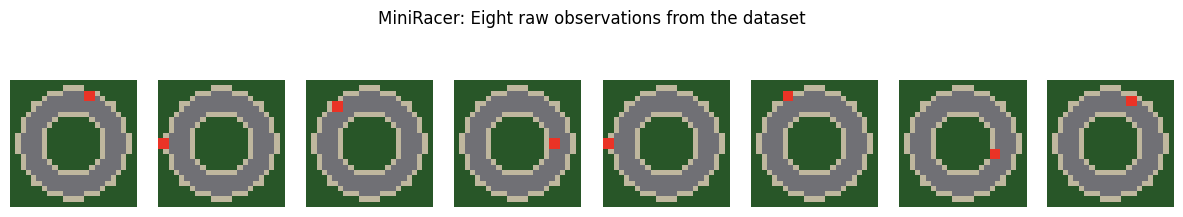

In [8]:
# 3. Collect Dataset of Random Play
env = MiniRacer(seed=SEED)
EPISODES, T = 150, 150

frames = np.zeros((EPISODES, T, 24, 24, 3), np.float32)
actions = np.zeros((EPISODES, T), np.int64)
rewards = np.zeros((EPISODES, T), np.float32)
rng = np.random.default_rng(SEED)

for e in range(EPISODES):
    obs = env.reset()
    for t in range(T):
        a = int(rng.integers(0, 3))
        frames[e, t], actions[e, t] = obs, a
        obs, r, done = env.step(a)
        rewards[e, t] = r

print(f"Dataset generated: {EPISODES} episodes x {T} steps = {EPISODES * T:,} frames ({frames.nbytes / 1e6:.1f} MB)")

# 4. Visualize 8 sample frames
fig, axes = plt.subplots(1, 8, figsize=(12, 1.9))
for i in range(8):
    axes[i].imshow(frames[i, i * 9])
    axes[i].axis("off")
fig.suptitle("MiniRacer: Eight raw observations from the dataset", y=1.12)
plt.tight_layout()
plt.show()

### SECTION : 2 || CONVOLUTIONAL VARIATIONAL AUTOENCODER

In [ ]:
import torch
import torch.nn as nn 

Z = 16 # Latent code size

# 1. Define the convolutional feature extractor
enc = nn.Sequential(
          # In : 3 channels out





)